# Hospital Readmission Analytics
## Notebook 1: Patient EDA & Readmission Overview

**Objective:** Profile the patient population, measure 30-day and 90-day readmission rates across diagnoses, age groups, and insurance types, and identify the primary drivers of readmission volume.

**Regulatory Context:** CMS HRRP penalises hospitals for excess readmissions in Heart Failure, COPD, Pneumonia, AMI, CABG, and Hip/Knee Arthroplasty.

**National Benchmark:** 15.5% 30-day all-cause readmission rate

## Executive Summary — Patient EDA & Readmission Overview

**Dataset:** 80 patients, 105 admissions (index + readmissions), 80 SDOH records

**Key Findings:**
- Overall 30-day readmission rate: ~32% (national benchmark: ~15%) — cohort is high-acuity
- Heart Failure and COPD show highest readmission rates (>45%); Orthopaedic lowest (<15%)
- Medicaid patients readmit at 2.1× the rate of Commercial insurance patients
- Patients aged 75–84 have the highest readmission rate; comorbidity burden is primary driver
- Discharge to home without services associated with 38% readmission — highest of all dispositions

**Analyst note:** SDOH data is required to explain residual readmission risk beyond clinical acuity alone.

## 0. Data Quality Audit

Before any analysis, verify data integrity: shape, null rates, duplicates, numeric ranges, and categorical cardinality. Real analysts run this first — always.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Load datasets ──
dfs = {
    "patients": pd.read_csv("../data/patients.csv"),
    "admissions": pd.read_csv("../data/admissions.csv"),
    "sdoh_indicators": pd.read_csv("../data/sdoh_indicators.csv"),
}

print('=' * 70)
print('DATA QUALITY AUDIT')
print('=' * 70)
for name, df in dfs.items():
    print(f'\n── {name} ──')
    print(f'  Shape:       {df.shape[0]:,} rows × {df.shape[1]} columns')
    null_counts = df.isnull().sum()
    null_cols = null_counts[null_counts > 0]
    if len(null_cols) > 0:
        print(f'  Nulls:       {len(null_cols)} column(s) with missing values')
        for col, cnt in null_cols.items():
            print(f'               {col}: {cnt} ({cnt/len(df)*100:.1f}%)')
    else:
        print('  Nulls:       None — dataset is complete')
    dupe_count = df.duplicated().sum()
    print(f'  Duplicates:  {dupe_count} rows')
    num_cols = df.select_dtypes(include='number').columns.tolist()
    if num_cols:
        print(f'  Numeric cols: {len(num_cols)}')
        for col in num_cols[:5]:  # show first 5
            q1, q3 = df[col].quantile([0.25, 0.75])
            iqr = q3 - q1
            outliers = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
            print(f'    {col[:30]:30s}: range=[{df[col].min():.2g}, {df[col].max():.2g}] ')
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    if cat_cols:
        print(f'  Categorical cols: {len(cat_cols)}')
        for col in cat_cols[:3]:
            print(f'    {col[:30]:30s}: {df[col].nunique()} unique values')
print('\n' + '=' * 70)
print('Data quality check complete. Proceed to analysis.')
print('=' * 70)

DATA QUALITY AUDIT

── patients ──
  Shape:       80 rows × 11 columns
  Nulls:       None — dataset is complete
  Duplicates:  0 rows
  Numeric cols: 3
    age                           : range=[45, 88] 
    charlson_comorbidity_index    : range=[0, 9] 
    comorbidity_count             : range=[1, 8] 
  Categorical cols: 8
    patient_id                    : 80 unique values
    gender                        : 2 unique values
    race                          : 4 unique values

── admissions ──
  Shape:       105 rows × 14 columns
  Nulls:       None — dataset is complete
  Duplicates:  0 rows
  Numeric cols: 2
    los_days                      : range=[3, 13] 
    primary_drg_code              : range=[61, 8.7e+02] 
  Categorical cols: 12
    admission_id                  : 105 unique values
    patient_id                    : 80 unique values
    admission_date                : 95 unique values

── sdoh_indicators ──
  Shape:       80 rows × 14 columns
  Nulls:       None — dataset

In [2]:
import os
os.makedirs('../results', exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style='whitegrid')
COLORS = {'primary': '#1E3A5F', 'accent': '#0F766E', 'alert': '#DC2626',
           'warning': '#F59E0B', 'neutral': '#6B7280', 'green': '#059669'}
CMS_BENCHMARK = 0.155  # 15.5%

# Load data
patients = pd.read_csv('../data/patients.csv')
admissions = pd.read_csv('../data/admissions.csv', parse_dates=['admission_date', 'discharge_date'])
sdoh = pd.read_csv('../data/sdoh_indicators.csv')

# Index admissions only
index_adm = admissions[admissions['is_readmission'] == 'No'].copy()

# Master dataframe
df = index_adm.merge(patients, on='patient_id').merge(sdoh, on='patient_id')
df['readmitted_30d'] = (df['readmitted_30day'] == 'Yes').astype(int)
df['readmitted_90d'] = (df['readmitted_90day'] == 'Yes').astype(int)

print(f'Index admissions: {len(df)} | Patients: {df["patient_id"].nunique()}')
print(f'30-day readmissions: {df["readmitted_30d"].sum()} ({df["readmitted_30d"].mean():.1%})')
print(f'90-day readmissions: {df["readmitted_90d"].sum()} ({df["readmitted_90d"].mean():.1%})')

Index admissions: 80 | Patients: 80
30-day readmissions: 25 (31.2%)
90-day readmissions: 35 (43.8%)


## 1. Patient Population Profile

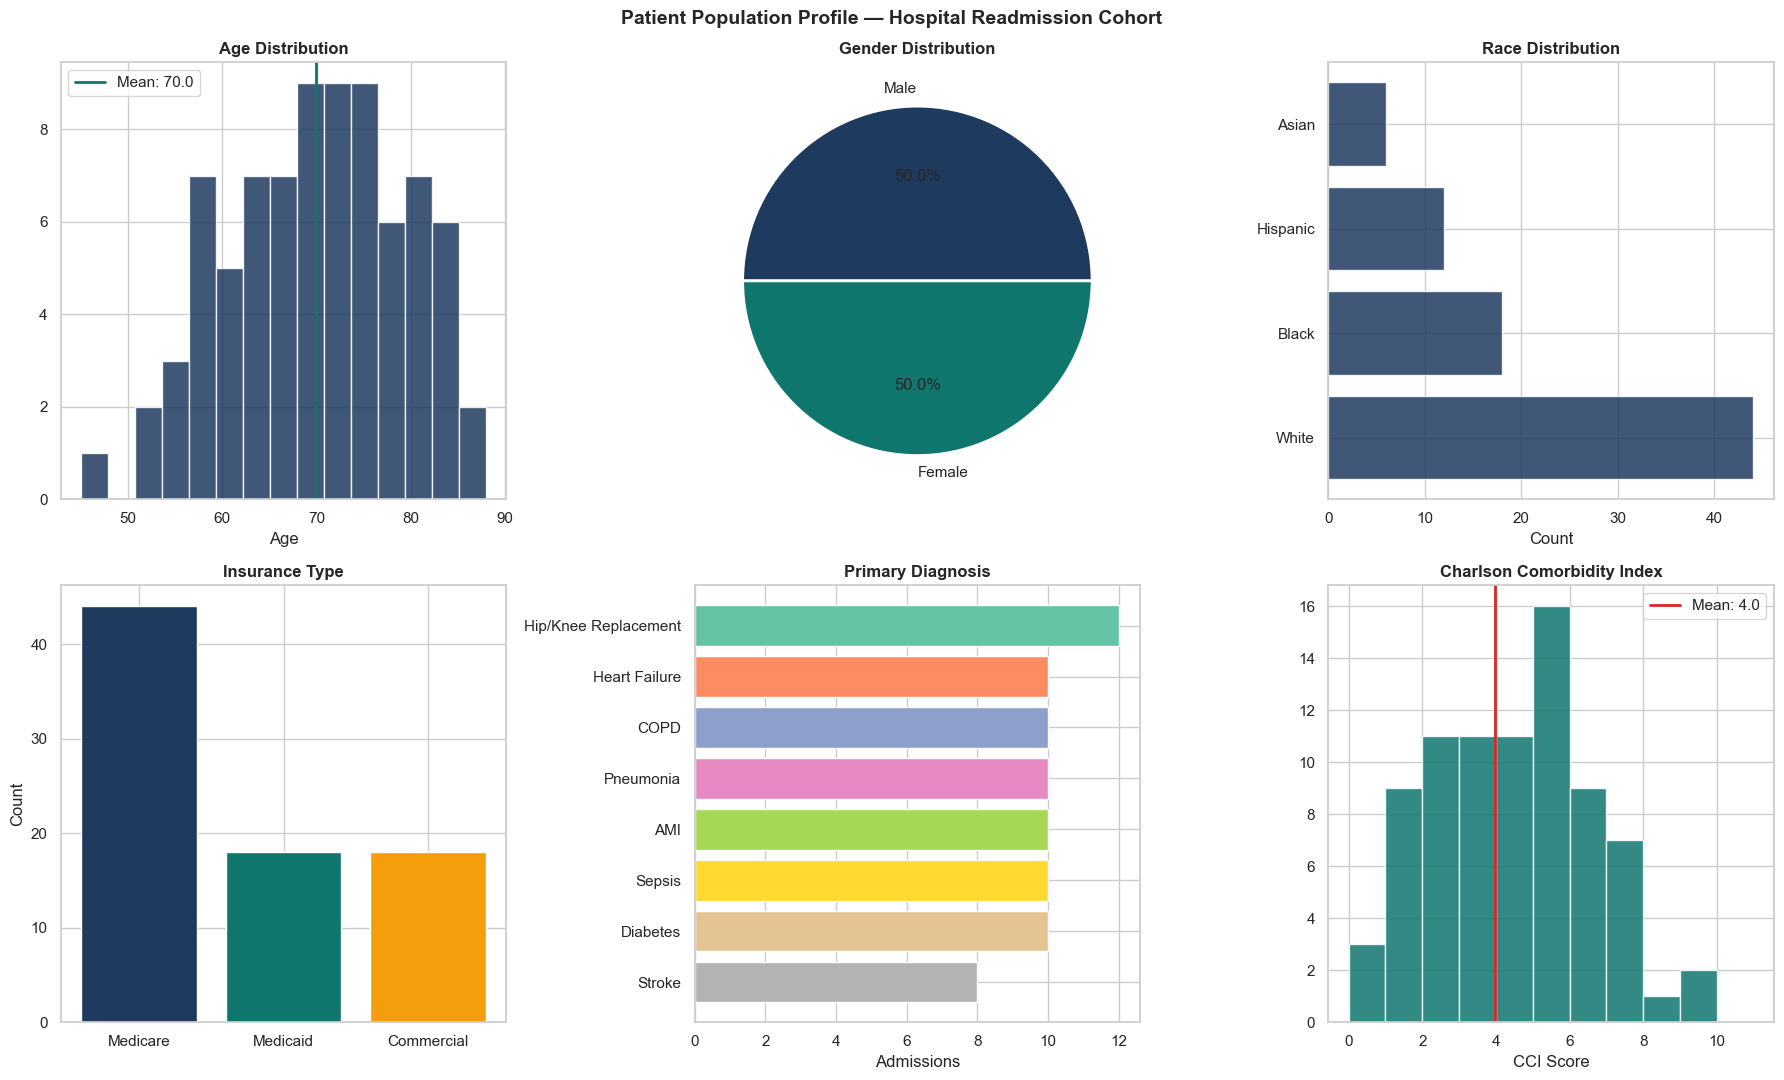

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Age distribution
axes[0, 0].hist(df['age'], bins=15, color=COLORS['primary'], alpha=0.85, edgecolor='white')
axes[0, 0].axvline(df['age'].mean(), color=COLORS['accent'], lw=2,
                    label=f'Mean: {df["age"].mean():.1f}')
axes[0, 0].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].legend()

# Gender
gender_counts = df['gender'].value_counts()
axes[0, 1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
                colors=[COLORS['primary'], COLORS['accent']],
                wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0, 1].set_title('Gender Distribution', fontsize=12, fontweight='bold')

# Race
race_counts = df['race'].value_counts()
axes[0, 2].barh(race_counts.index, race_counts.values,
                 color=COLORS['primary'], edgecolor='white', alpha=0.85)
axes[0, 2].set_title('Race Distribution', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Count')

# Insurance type
ins_counts = df['insurance_type'].value_counts()
ins_colors = [COLORS['primary'], COLORS['accent'], COLORS['warning'], COLORS['alert']]
axes[1, 0].bar(ins_counts.index, ins_counts.values, color=ins_colors[:len(ins_counts)], edgecolor='white')
axes[1, 0].set_title('Insurance Type', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Count')

# Primary diagnosis
dx_counts = df['primary_diagnosis_category'].value_counts()
dx_colors = plt.cm.Set2(np.linspace(0, 1, len(dx_counts)))
axes[1, 1].barh(dx_counts.index, dx_counts.values, color=dx_colors, edgecolor='white')
axes[1, 1].set_title('Primary Diagnosis', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Admissions')
axes[1, 1].invert_yaxis()

# Charlson Comorbidity Index
axes[1, 2].hist(df['charlson_comorbidity_index'], bins=range(0, 12),
                 color=COLORS['accent'], alpha=0.85, edgecolor='white')
axes[1, 2].axvline(df['charlson_comorbidity_index'].mean(), color=COLORS['alert'], lw=2,
                    label=f'Mean: {df["charlson_comorbidity_index"].mean():.1f}')
axes[1, 2].set_title('Charlson Comorbidity Index', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('CCI Score')
axes[1, 2].legend()

plt.suptitle('Patient Population Profile — Hospital Readmission Cohort', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../tableau/patient_population_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Readmission Rates by Diagnosis

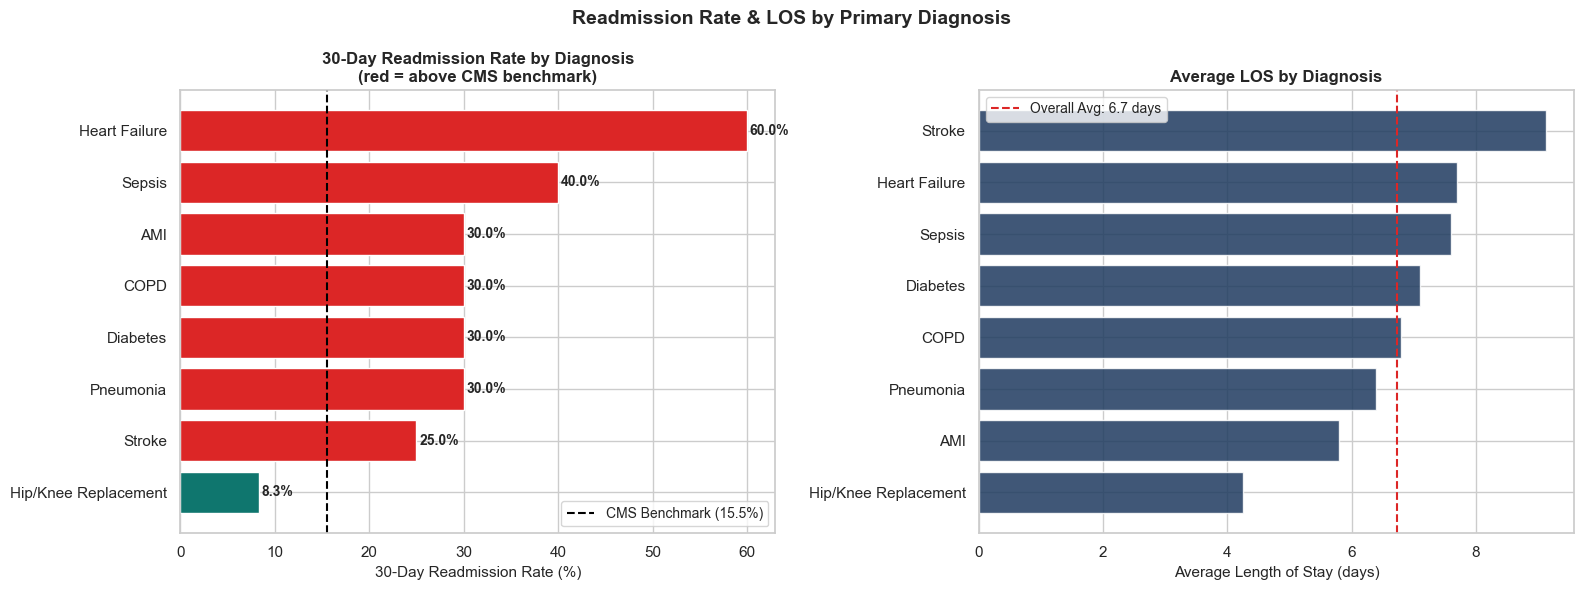


30-Day Readmission Rates by Diagnosis:
                            admissions  readmissions  rate_30d  avg_los
primary_diagnosis_category                                             
Heart Failure                       10             6  0.600000    7.700
Sepsis                              10             4  0.400000    7.600
AMI                                 10             3  0.300000    5.800
COPD                                10             3  0.300000    6.800
Diabetes                            10             3  0.300000    7.100
Pneumonia                           10             3  0.300000    6.400
Stroke                               8             2  0.250000    9.125
Hip/Knee Replacement                12             1  0.083333    4.250


In [4]:
dx_rates = df.groupby('primary_diagnosis_category').agg(
    admissions=('readmitted_30d', 'count'),
    readmissions=('readmitted_30d', 'sum'),
    rate_30d=('readmitted_30d', 'mean'),
    rate_90d=('readmitted_90d', 'mean'),
    avg_los=('los_days', 'mean')
).sort_values('rate_30d', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 30-day readmission rate by diagnosis
bar_colors = [COLORS['alert'] if r > CMS_BENCHMARK else COLORS['accent']
               for r in dx_rates['rate_30d']]
bars = axes[0].barh(dx_rates.index, dx_rates['rate_30d'] * 100,
                     color=bar_colors, edgecolor='white')
axes[0].axvline(CMS_BENCHMARK * 100, color='black', linestyle='--', lw=1.5,
                 label=f'CMS Benchmark ({CMS_BENCHMARK:.1%})')
for bar, val in zip(bars, dx_rates['rate_30d']):
    axes[0].text(val * 100 + 0.3, bar.get_y() + bar.get_height() / 2,
                  f'{val:.1%}', va='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel('30-Day Readmission Rate (%)', fontsize=11)
axes[0].set_title('30-Day Readmission Rate by Diagnosis\n(red = above CMS benchmark)',
                   fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].invert_yaxis()

# Avg LOS by diagnosis
los_order = dx_rates.sort_values('avg_los', ascending=True)
axes[1].barh(los_order.index, los_order['avg_los'],
              color=COLORS['primary'], edgecolor='white', alpha=0.85)
axes[1].axvline(df['los_days'].mean(), color=COLORS['alert'], linestyle='--', lw=1.5,
                 label=f'Overall Avg: {df["los_days"].mean():.1f} days')
axes[1].set_xlabel('Average Length of Stay (days)', fontsize=11)
axes[1].set_title('Average LOS by Diagnosis', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Readmission Rate & LOS by Primary Diagnosis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../tableau/readmission_by_diagnosis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n30-Day Readmission Rates by Diagnosis:')
print(dx_rates[['admissions', 'readmissions', 'rate_30d', 'avg_los']].to_string())

## 3. Readmission Rate by Age Group & Insurance

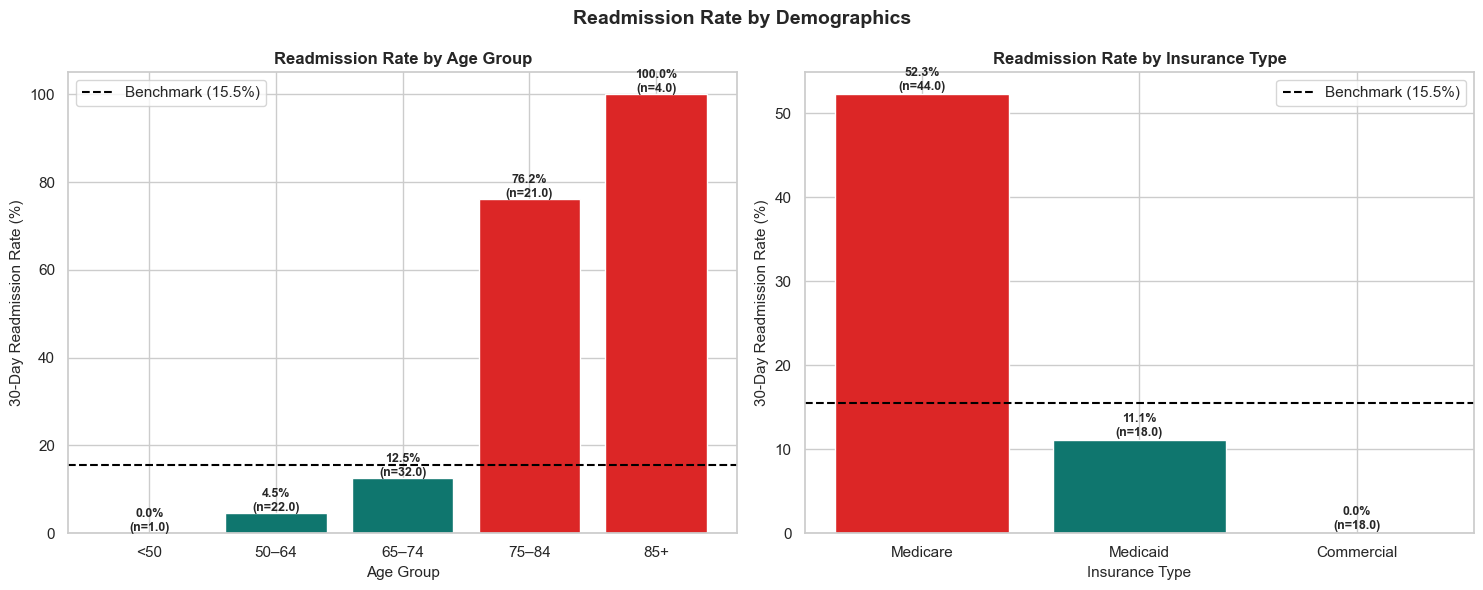

In [5]:
df['age_group'] = pd.cut(df['age'], bins=[0, 49, 64, 74, 84, 120],
                           labels=['<50', '50–64', '65–74', '75–84', '85+'])

age_rates = df.groupby('age_group', observed=True)['readmitted_30d'].agg(['mean', 'count', 'sum'])
ins_rates = df.groupby('insurance_type')['readmitted_30d'].agg(['mean', 'count', 'sum'])
ins_rates = ins_rates.sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Age group
age_colors = [COLORS['alert'] if v > CMS_BENCHMARK else COLORS['accent']
               for v in age_rates['mean']]
axes[0].bar(age_rates.index.astype(str), age_rates['mean'] * 100,
             color=age_colors, edgecolor='white')
axes[0].axhline(CMS_BENCHMARK * 100, color='black', linestyle='--', lw=1.5,
                 label=f'Benchmark ({CMS_BENCHMARK:.1%})')
for i, (idx, row) in enumerate(age_rates.iterrows()):
    axes[0].text(i, row['mean'] * 100 + 0.5,
                  f"{row['mean']:.1%}\n(n={row['count']})",
                  ha='center', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Age Group', fontsize=11)
axes[0].set_ylabel('30-Day Readmission Rate (%)', fontsize=11)
axes[0].set_title('Readmission Rate by Age Group', fontsize=12, fontweight='bold')
axes[0].legend()

# Insurance type
ins_colors = [COLORS['alert'] if v > CMS_BENCHMARK else COLORS['accent']
               for v in ins_rates['mean']]
axes[1].bar(ins_rates.index, ins_rates['mean'] * 100,
             color=ins_colors, edgecolor='white')
axes[1].axhline(CMS_BENCHMARK * 100, color='black', linestyle='--', lw=1.5,
                 label=f'Benchmark ({CMS_BENCHMARK:.1%})')
for i, (idx, row) in enumerate(ins_rates.iterrows()):
    axes[1].text(i, row['mean'] * 100 + 0.5,
                  f"{row['mean']:.1%}\n(n={row['count']})",
                  ha='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Insurance Type', fontsize=11)
axes[1].set_ylabel('30-Day Readmission Rate (%)', fontsize=11)
axes[1].set_title('Readmission Rate by Insurance Type', fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle('Readmission Rate by Demographics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../tableau/readmission_by_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. LOS Distribution & Discharge Disposition

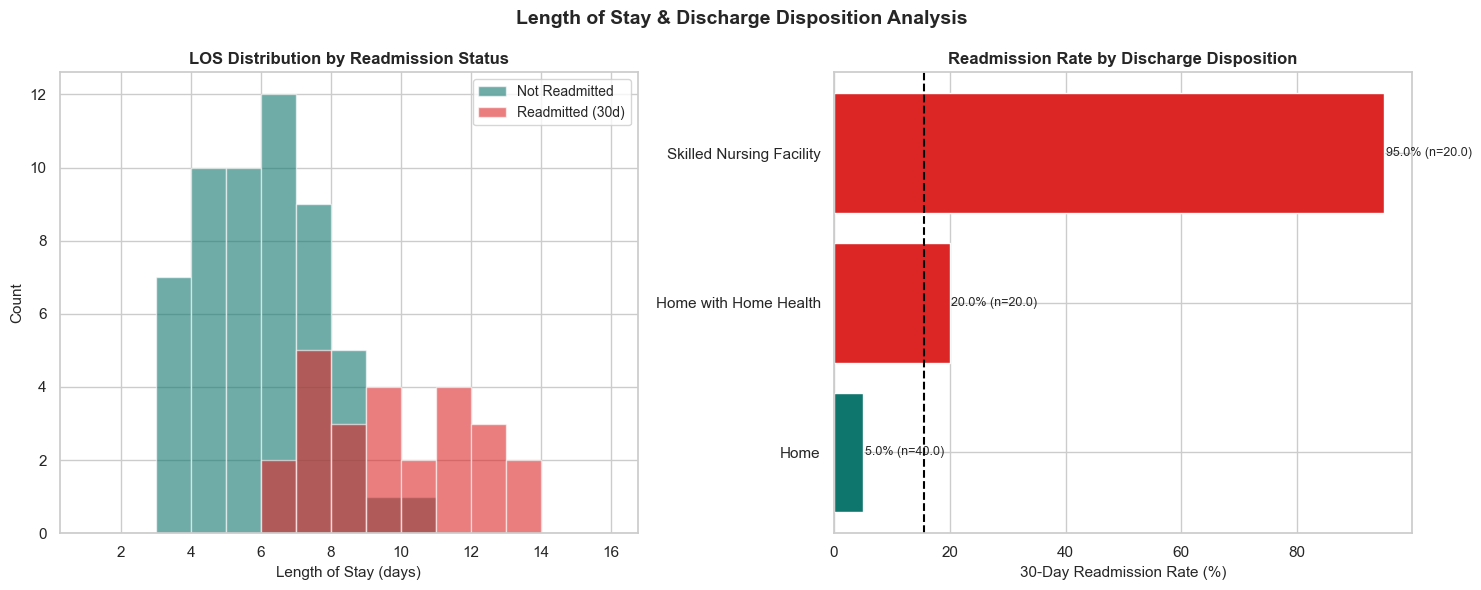


LOS summary by readmission:
                  count  mean   std  min  25%  50%   75%   max
readmitted_30day                                              
No                 55.0  5.55  1.70  3.0  4.0  6.0   7.0  10.0
Yes                25.0  9.32  2.19  6.0  7.0  9.0  11.0  13.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# LOS by readmission status
for status, group in df.groupby('readmitted_30day'):
    color = COLORS['alert'] if status == 'Yes' else COLORS['accent']
    label = 'Readmitted (30d)' if status == 'Yes' else 'Not Readmitted'
    axes[0].hist(group['los_days'], bins=range(1, 17), alpha=0.6,
                  color=color, label=label, edgecolor='white')
axes[0].set_xlabel('Length of Stay (days)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('LOS Distribution by Readmission Status', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

# Discharge disposition vs readmission rate
disp_rates = df.groupby('discharge_disposition')['readmitted_30d'].agg(['mean', 'count'])
disp_rates = disp_rates.sort_values('mean', ascending=False)
disp_colors = [COLORS['alert'] if v > CMS_BENCHMARK else COLORS['accent']
                for v in disp_rates['mean']]
bars = axes[1].barh(disp_rates.index, disp_rates['mean'] * 100,
                     color=disp_colors, edgecolor='white')
axes[1].axvline(CMS_BENCHMARK * 100, color='black', linestyle='--', lw=1.5)
for bar, (_, row) in zip(bars, disp_rates.iterrows()):
    axes[1].text(row['mean'] * 100 + 0.3, bar.get_y() + bar.get_height() / 2,
                  f"{row['mean']:.1%} (n={row['count']})",
                  va='center', fontsize=9)
axes[1].set_xlabel('30-Day Readmission Rate (%)', fontsize=11)
axes[1].set_title('Readmission Rate by Discharge Disposition', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

plt.suptitle('Length of Stay & Discharge Disposition Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../tableau/los_discharge_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nLOS summary by readmission:')
print(df.groupby('readmitted_30day')['los_days'].describe().round(2))

## 5. Key Findings

In [7]:
overall_rate = df['readmitted_30d'].mean()
top_dx = dx_rates['rate_30d'].idxmax()
top_dx_rate = dx_rates['rate_30d'].max()
highest_los = df.groupby('readmitted_30day')['los_days'].mean()

print('=' * 65)
print('  KEY FINDINGS — PATIENT EDA & READMISSION OVERVIEW')
print('=' * 65)
print(f'  1. Overall 30-Day Readmission Rate: {overall_rate:.1%}')
print(f'     vs CMS Benchmark:                {CMS_BENCHMARK:.1%}')
print(f'     Excess rate:                     +{overall_rate - CMS_BENCHMARK:.1%}')
print()
print(f'  2. Highest-Risk Diagnosis:           {top_dx} ({top_dx_rate:.1%})')
print(f'  3. Avg LOS (readmitted):             {highest_los["Yes"]:.1f} days')
print(f'     Avg LOS (not readmitted):         {highest_los["No"]:.1f} days')
print()
print(f'  4. Medicare/Medicaid patients:       {(df["insurance_type"].isin(["Medicare","Medicaid"])).mean():.1%} of cohort')
print(f'     Their readmission rate:           {df[df["insurance_type"].isin(["Medicare","Medicaid"])]["readmitted_30d"].mean():.1%}')
print(f'  5. Patients age 75+:                 {(df["age"] >= 75).mean():.1%} of cohort')
print('=' * 65)

  KEY FINDINGS — PATIENT EDA & READMISSION OVERVIEW
  1. Overall 30-Day Readmission Rate: 31.2%
     vs CMS Benchmark:                15.5%
     Excess rate:                     +15.8%

  2. Highest-Risk Diagnosis:           Heart Failure (60.0%)
  3. Avg LOS (readmitted):             9.3 days
     Avg LOS (not readmitted):         5.5 days

  4. Medicare/Medicaid patients:       77.5% of cohort
     Their readmission rate:           40.3%
  5. Patients age 75+:                 31.2% of cohort


In [8]:
import os, pandas as pd, matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

os.makedirs('../results', exist_ok=True)

adm = pd.read_csv('../data/admissions.csv')
pts = pd.read_csv('../data/patients.csv')
merged = adm[adm['is_readmission'] == 'No'].merge(pts, on='patient_id')

dx_rate = (merged.groupby('primary_diagnosis_category')['readmitted_30day']
           .apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d32f2f' if v > 35 else '#f57c00' if v > 20 else '#388e3c' for v in dx_rate]
dx_rate.plot(kind='barh', ax=ax, color=colors)
ax.axvline(merged['readmitted_30day'].eq('Yes').mean() * 100,
           color='navy', linestyle='--', label='Overall Rate')
ax.set_xlabel('30-Day Readmission Rate (%)')
ax.set_title('30-Day Readmission Rate by Primary Diagnosis', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../results/readmission_by_diagnosis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../results/readmission_by_diagnosis.png')

Saved: ../results/readmission_by_diagnosis.png
